In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [11]:
train = pd.read_csv(
    "/kaggle/input/datasets/chakramlops/rossmann-store-sales-dataset/train.csv",
    dtype={"StateHoliday": str},
    low_memory=False
)

store = pd.read_csv(
    "/kaggle/input/datasets/chakramlops/rossmann-store-sales-dataset/store.csv",
    low_memory=False
)

In [12]:
print("Train Shape:", train.shape)
print("Store Shape:", store.shape)

train.head()

Train Shape: (1017209, 9)
Store Shape: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [13]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [14]:
train.info()

print("="*60)

store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assort

In [15]:
train.isnull().sum().sort_values(ascending=False)
store.isnull().sum().sort_values(ascending=False)

PromoInterval                544
Promo2SinceYear              544
Promo2SinceWeek              544
CompetitionOpenSinceYear     354
CompetitionOpenSinceMonth    354
CompetitionDistance            3
StoreType                      0
Store                          0
Assortment                     0
Promo2                         0
dtype: int64

In [16]:
df = train.merge(store, on="Store", how="left")

print(df.shape)

df.head()

(1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,1017209.0,558.429727,321.908651,1.0,280.0,558.0,838.0,1115.0
DayOfWeek,1017209.0,3.998341,1.997391,1.0,2.0,4.0,6.0,7.0
Sales,1017209.0,5773.818972,3849.926175,0.0,3727.0,5744.0,7856.0,41551.0
Customers,1017209.0,633.145946,464.411734,0.0,405.0,609.0,837.0,7388.0
Open,1017209.0,0.830107,0.375539,0.0,1.0,1.0,1.0,1.0
Promo,1017209.0,0.381515,0.485759,0.0,0.0,0.0,1.0,1.0
SchoolHoliday,1017209.0,0.178647,0.383056,0.0,0.0,0.0,0.0,1.0
CompetitionDistance,1014567.0,5430.085652,7715.323700,20.0,710.0,2330.0,6890.0,75860.0
CompetitionOpenSinceMonth,693861.0,7.222866,3.211832,1.0,4.0,8.0,10.0,12.0
CompetitionOpenSinceYear,693861.0,2008.690228,5.992644,1900.0,2006.0,2010.0,2013.0,2015.0


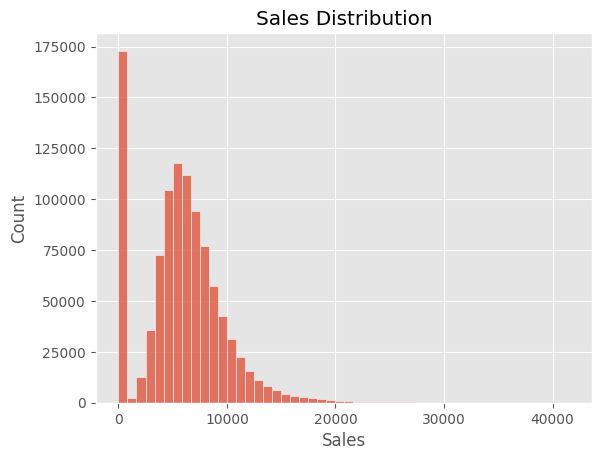

In [19]:
sns.histplot(train["Sales"], bins=50)
plt.title("Sales Distribution")
plt.show()

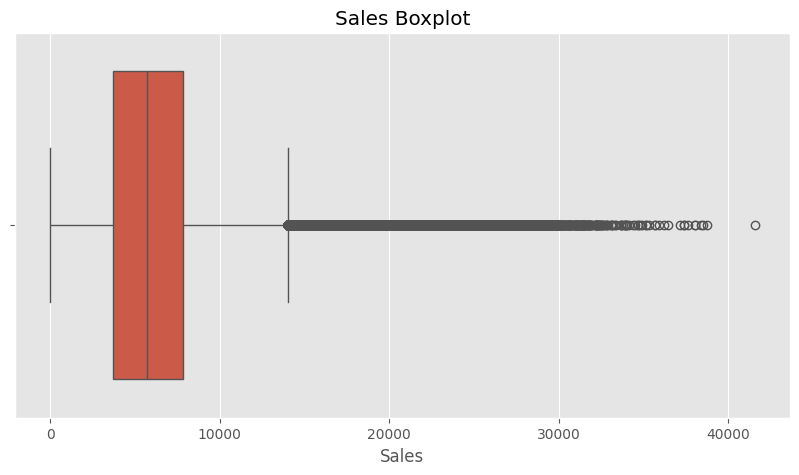

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(x=train["Sales"])
plt.title("Sales Boxplot")
plt.show()

In [21]:
train.groupby("Open")["Sales"].mean()
train.groupby("Promo")["Sales"].mean()

Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64

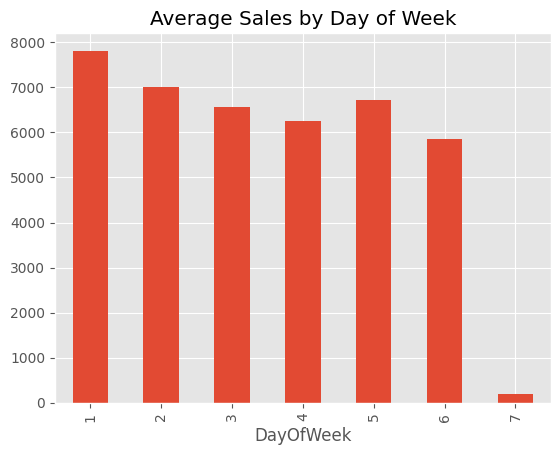

In [22]:
train.groupby("DayOfWeek")["Sales"].mean().plot(kind="bar")
plt.title("Average Sales by Day of Week")
plt.show()

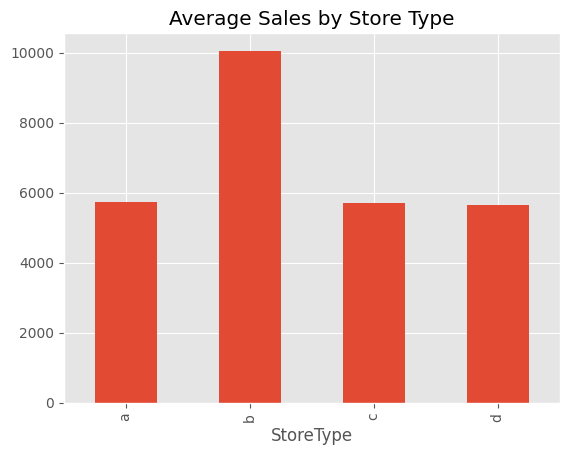

In [23]:
df.groupby("StoreType")["Sales"].mean().plot(kind="bar")
plt.title("Average Sales by Store Type")
plt.show()

# Exploratory Data Analysis (EDA)

Objective:
Understand the factors affecting Rossmann store sales and identify meaningful business insights before feature engineering and model building.

In [24]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.day_name()

df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,Weekday
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2015,7,31,Friday
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,Friday
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,Friday
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN,2015,7,31,Friday
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN,2015,7,31,Friday


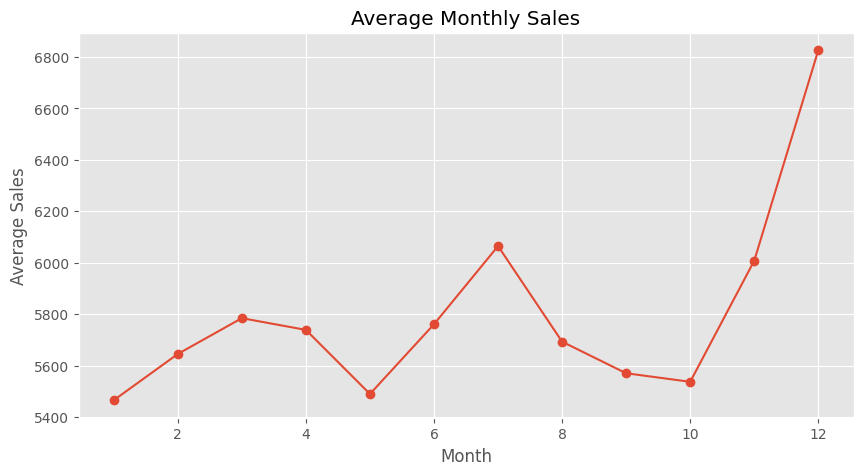

In [25]:
monthly_sales = df.groupby("Month")["Sales"].mean()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker="o")
plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.grid(True)
plt.show()

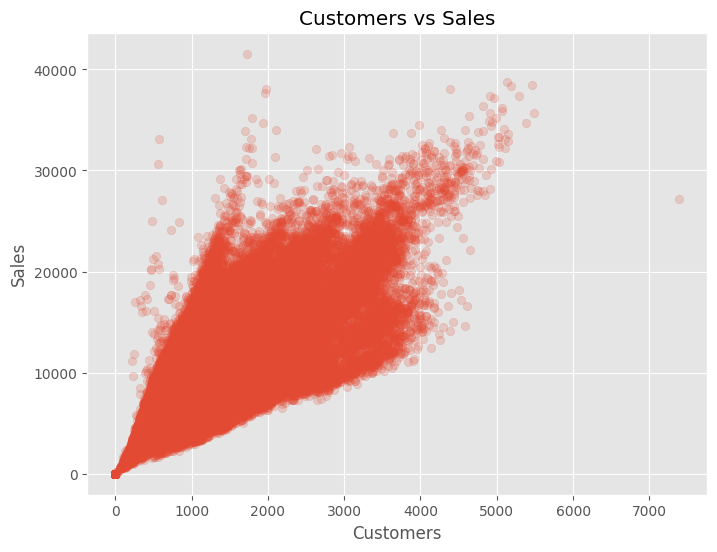

In [26]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["Customers"],
    df["Sales"],
    alpha=0.2
)

plt.title("Customers vs Sales")
plt.xlabel("Customers")
plt.ylabel("Sales")

plt.show()

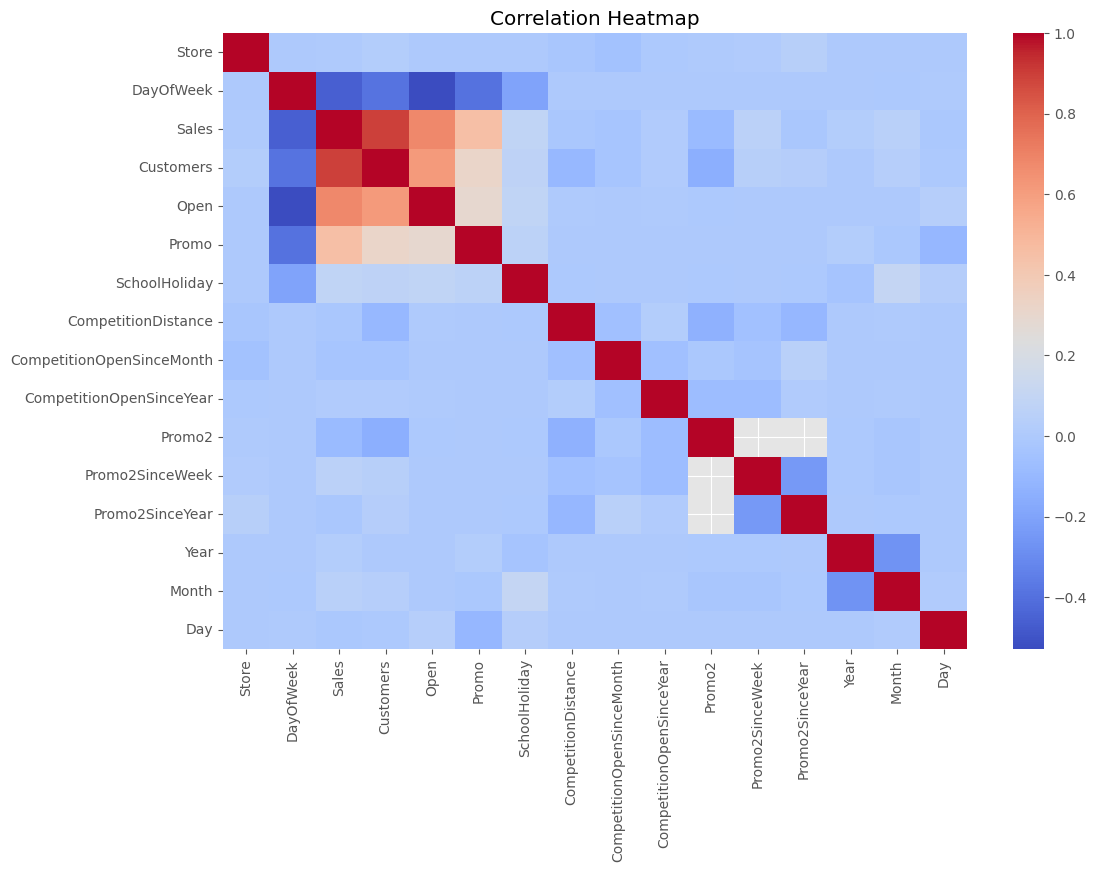

In [27]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

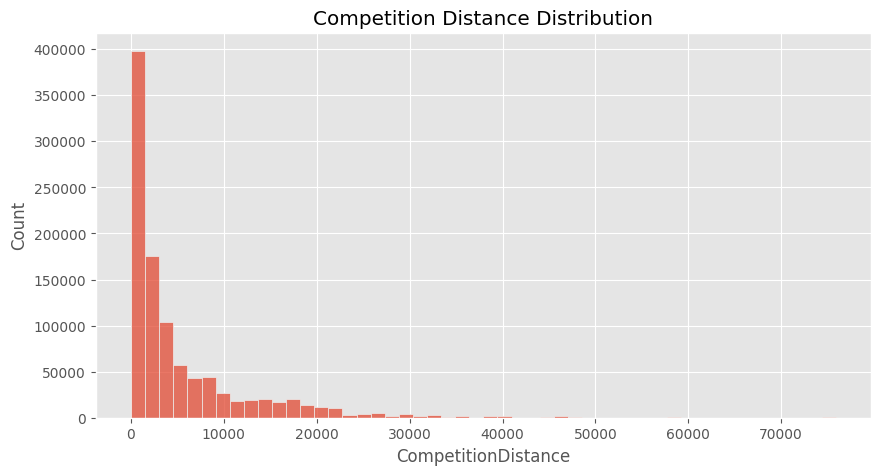

In [28]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["CompetitionDistance"],
    bins=50
)

plt.title("Competition Distance Distribution")

plt.show()

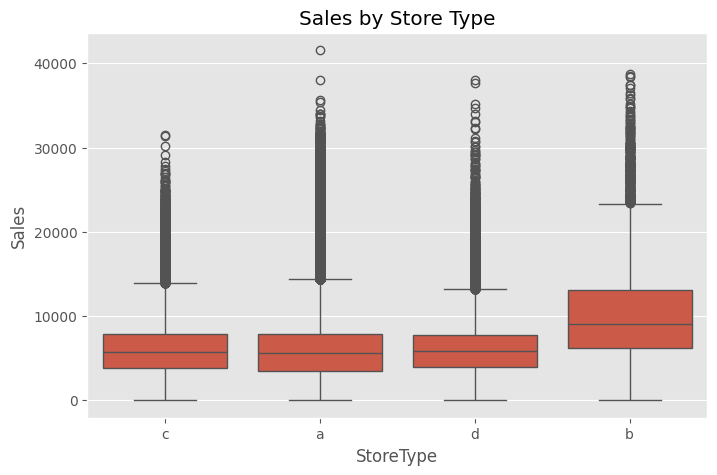

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["StoreType"],
    y=df["Sales"]
)

plt.title("Sales by Store Type")

plt.show()

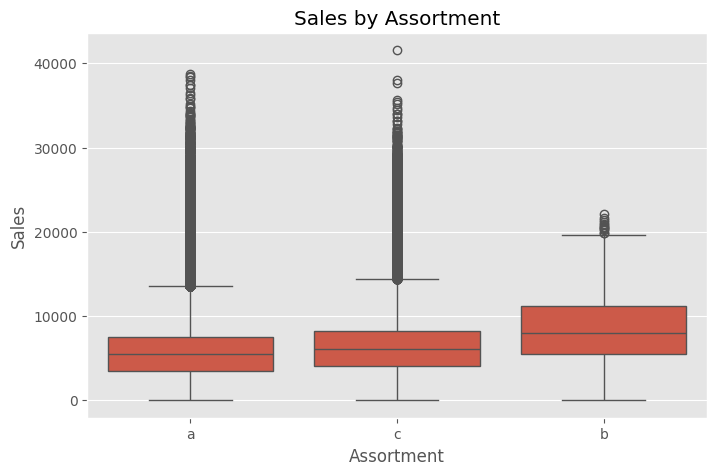

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Assortment"],
    y=df["Sales"]
)

plt.title("Sales by Assortment")

plt.show()

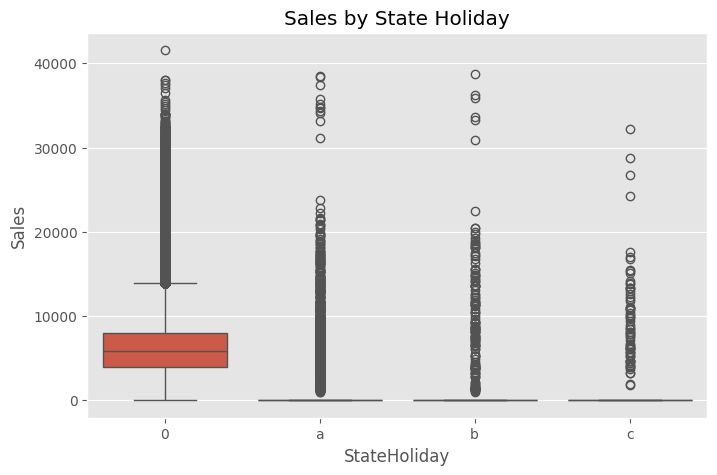

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["StateHoliday"],
    y=df["Sales"]
)

plt.title("Sales by State Holiday")

plt.show()

In [32]:
df.groupby("SchoolHoliday")["Sales"].mean()

SchoolHoliday
0    5620.979034
1    6476.522207
Name: Sales, dtype: float64

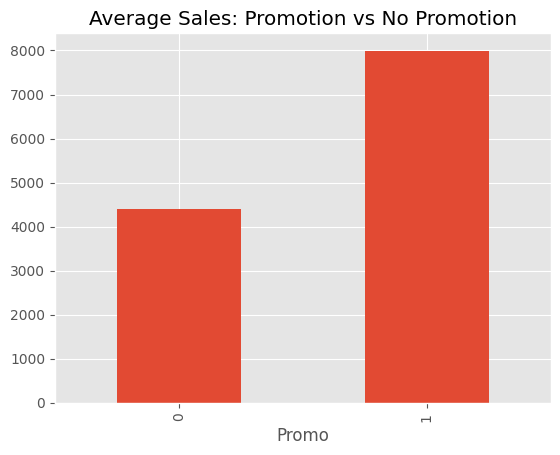

In [33]:
promo_sales = df.groupby("Promo")["Sales"].mean()

promo_sales.plot(kind="bar")

plt.title("Average Sales: Promotion vs No Promotion")

plt.show()

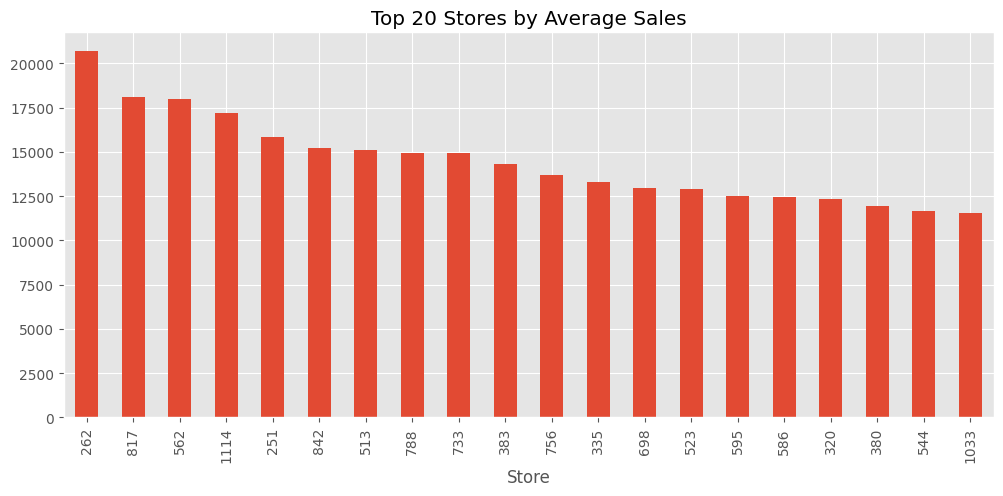

In [34]:
top20 = df.groupby("Store")["Sales"].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(12,5))

top20.plot(kind="bar")

plt.title("Top 20 Stores by Average Sales")

plt.show()

In [35]:
df[df["Open"]==0]["Sales"].describe()

count    172817.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: Sales, dtype: float64

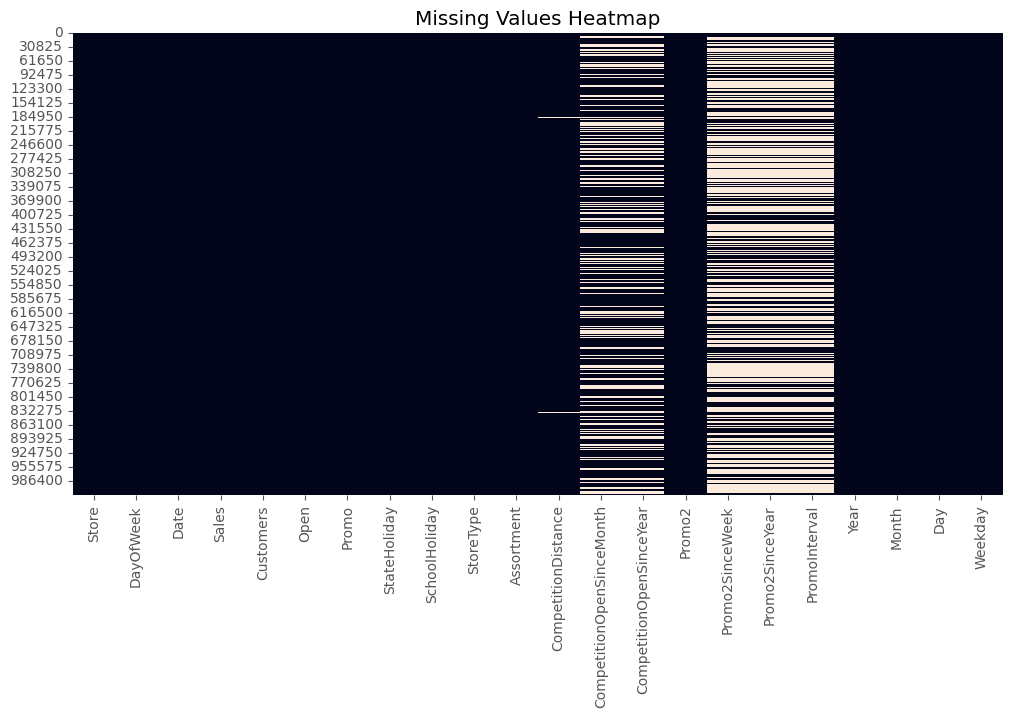

In [36]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")

plt.show()

In [37]:
df.duplicated().sum()

np.int64(0)

# Key Business Insights

### 1. Customer count has the strongest positive relationship with sales.
The scatter plot shows a clear upward trend, indicating that stores with more customers consistently generate higher sales. Customer traffic is one of the most influential business drivers.

### 2. Promotional campaigns significantly increase sales.
Stores running promotions achieve substantially higher average sales than stores without promotions, highlighting the effectiveness of promotional strategies in driving revenue.

### 3. Sales vary across different store types.
Store Type B exhibits the highest median sales among all store categories, suggesting that store format and business model play an important role in overall performance.

### 4. Sales demonstrate seasonal patterns throughout the year.
Average monthly sales fluctuate across months, with noticeable increases during mid-year and especially toward the end of the year, indicating strong seasonal demand.

### 5. Holiday periods influence purchasing behavior.
Sales distributions differ between normal days and state holidays, implying that holidays have a measurable impact on customer shopping patterns and should be considered during forecasting.